In [1]:
import os, random, hashlib
import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import efficientnet_b0
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SR = 22050
DURATION = 3.0
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)
ROOT_DIR = r"C:\Users\User\OneDrive\Desktop\major project\acoustic_audio"


cuda


In [ ]:
# Count samples per class
counts = {}
for cls in os.listdir(ROOT_DIR):
    folder = os.path.join(ROOT_DIR, cls)
    if os.path.isdir(folder):
        counts[cls] = len([f for f in os.listdir(folder) if f.endswith(".wav")])

print("Samples per class:", counts)

# Remove classes with <50 samples
MIN_SAMPLES = 50
valid_classes = [cls for cls, cnt in counts.items() if cnt >= MIN_SAMPLES]
print("Keeping classes:", valid_classes)

# Function to hash files (for duplicate removal)
def file_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


Samples per class: {'Atlantic_Spotted_Dolphin': 58, 'Bearded_Seal': 37, 'Beluga_White_Whale': 50, 'Bottlenose_Dolphin': 24, 'Bowhead_Whale': 60, 'Clymene_Dolphin': 63, 'Common_Dolphin': 52, 'False_Killer_Whale': 59, 'Fin_Finback_Whale': 50, 'Frasers_Dolphin': 87, 'Grampus_Rissos_Dolphin': 67, 'Harp_Seal': 47, 'Humpback_Whale': 64, 'Killer_Whale': 35, 'Leopard_Seal': 10, 'Long_Finned_Pilot_Whale': 70, 'Melon_Headed_Whale': 63, 'Minke_Whale': 17, 'Narwhal': 50, 'Northern_Right_Whale': 54, 'Pantropical_Spotted_Dolphin': 66, 'Ross_Seal': 50, 'Rough_Toothed_Dolphin': 50, 'Short_Finned_Pilot_Whale': 67, 'Southern_Right_Whale': 25, 'Sperm_Whale': 75, 'Spinner_Dolphin': 114, 'Striped_Dolphin': 81, 'Walrus': 38, 'Weddell_Seal': 2, 'White_beaked_Dolphin': 57, 'White_sided_Dolphin': 55}
Keeping classes: ['Atlantic_Spotted_Dolphin', 'Beluga_White_Whale', 'Bowhead_Whale', 'Clymene_Dolphin', 'Common_Dolphin', 'False_Killer_Whale', 'Fin_Finback_Whale', 'Frasers_Dolphin', 'Grampus_Rissos_Dolphin', 'Hu

In [4]:
def spec_augment(mel_tensor, num_masks=2, freq_mask=15, time_mask=30):
    _, n_mels, n_steps = mel_tensor.shape
    for _ in range(num_masks):
        # Frequency Mask
        f = random.randint(0, freq_mask)
        f0 = random.randint(0, n_mels - f)
        mel_tensor[:, f0:f0+f, :] = 0

        # Time Mask
        t = random.randint(0, time_mask)
        t0 = random.randint(0, n_steps - t)
        mel_tensor[:, :, t0:t0+t] = 0
    return mel_tensor


In [5]:
class WhaleDataset(Dataset):
    def __init__(self, root_dir, sr=SR, duration=DURATION, n_mels=N_MELS, mode="train"):
        self.root_dir = root_dir
        self.sr = sr
        self.duration = duration
        self.n_samples = int(sr * duration)
        self.n_mels = n_mels
        self.mode = mode

        self.filepaths, self.labels = [], []
        self.class_names = sorted([c for c in os.listdir(root_dir) if c in valid_classes])

        seen_hashes = set()
        for idx, label in enumerate(self.class_names):
            folder = os.path.join(root_dir, label)
            for f in os.listdir(folder):
                if f.endswith(".wav"):
                    path = os.path.join(folder, f)

                    # Remove duplicates
                    h = file_hash(path)
                    if h in seen_hashes:
                        continue
                    seen_hashes.add(h)

                    self.filepaths.append(path)
                    self.labels.append(idx)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]

        # Load audio
        y, sr = librosa.load(path, sr=self.sr)
        if len(y) < self.n_samples:
            y = np.pad(y, (0, self.n_samples - len(y)))
        else:
            y = y[:self.n_samples]

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=self.n_mels,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

        mel_tensor = torch.tensor(mel_db).unsqueeze(0).float()

        # Apply SpecAugment in training mode
        if self.mode == "train":
            mel_tensor = spec_augment(mel_tensor)

        return mel_tensor, label


In [ ]:
dataset = WhaleDataset(ROOT_DIR, mode="train")

train_idx, val_idx = train_test_split(range(len(dataset)),
                                      test_size=0.2,
                                      stratify=dataset.labels,
                                      random_state=42)

train_set = torch.utils.data.Subset(dataset, train_idx)
val_set = torch.utils.data.Subset(dataset, val_idx)

# Change mode for validation (no augment)
val_set.dataset.mode = "val"

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(dataset.class_names)
print("Final Classes:", dataset.class_names)


Final Classes: ['Atlantic_Spotted_Dolphin', 'Beluga_White_Whale', 'Bowhead_Whale', 'Clymene_Dolphin', 'Common_Dolphin', 'False_Killer_Whale', 'Fin_Finback_Whale', 'Frasers_Dolphin', 'Grampus_Rissos_Dolphin', 'Humpback_Whale', 'Long_Finned_Pilot_Whale', 'Melon_Headed_Whale', 'Narwhal', 'Northern_Right_Whale', 'Pantropical_Spotted_Dolphin', 'Ross_Seal', 'Rough_Toothed_Dolphin', 'Short_Finned_Pilot_Whale', 'Sperm_Whale', 'Spinner_Dolphin', 'Striped_Dolphin', 'White_beaked_Dolphin', 'White_sided_Dolphin']


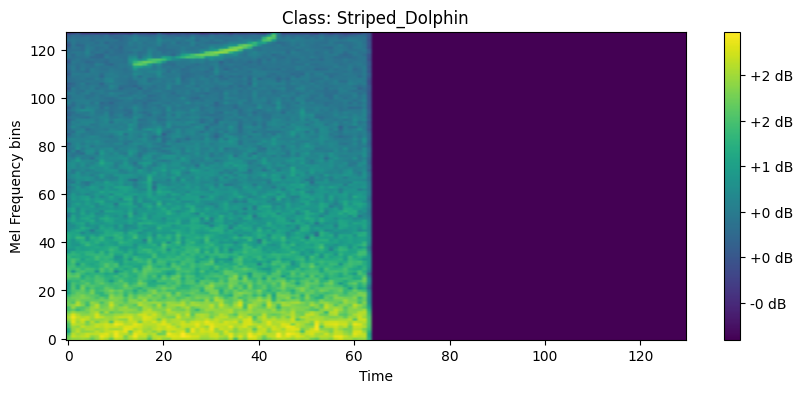

In [7]:
import matplotlib.pyplot as plt

mels, labels = next(iter(train_loader))

# Pick the first sample
mel = mels[12].squeeze(0).numpy()  # shape [n_mels, time]
label = labels[12].item()

plt.figure(figsize=(10, 4))
plt.imshow(mel, aspect="auto", origin="lower")
plt.colorbar(format="%+2.0f dB")
plt.title(f"Class: {dataset.class_names[label]}")
plt.xlabel("Time")
plt.ylabel("Mel Frequency bins")
plt.show()


In [ ]:
# ==========================
# 6. Models (ResNet50 / EfficientNet)
# ==========================
def build_resnet50(num_classes):
    model = models.resnet50(pretrained=True)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_resnet50(num_classes).to(DEVICE)


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def train_model(model, train_loader, val_loader, epochs):
    best_acc = 0
    epochs_count =  []
    train_acc_history = []
    val_acc_history = []
    train_loss_history = []
    val_loss_history = []
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, correct, total = 0, 0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

        train_acc = correct / total
        train_acc_history.append(train_acc)

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                outputs = model(X)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()

        val_acc = correct / total
        val_acc_history.append(val_acc)
        scheduler.step()
        train_loss_history.append(train_loss / len(train_loader))
        epochs_count.append(epoch+1)
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}")
        val_loss_history.append(val_loss / len(val_loader))
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

    print("Best Val Acc:", best_acc)
    return train_acc_history, val_acc_history, train_loss_history, epochs_count, val_loss_history
    

train_acc_history, val_acc_history, train_loss_history, epochs_count, val_loss_history= train_model(model, train_loader, val_loader, EPOCHS)


Epoch [1/50] Train Loss: 2.3485, Train Acc: 0.3405, Val Acc: 0.4586
Epoch [2/50] Train Loss: 1.1518, Train Acc: 0.7061, Val Acc: 0.7310
Epoch [3/50] Train Loss: 0.5870, Train Acc: 0.8531, Val Acc: 0.7897
Epoch [4/50] Train Loss: 0.3771, Train Acc: 0.9153, Val Acc: 0.8310
Epoch [5/50] Train Loss: 0.2145, Train Acc: 0.9507, Val Acc: 0.7931
Epoch [6/50] Train Loss: 0.1431, Train Acc: 0.9680, Val Acc: 0.8241
Epoch [7/50] Train Loss: 0.1265, Train Acc: 0.9663, Val Acc: 0.8172
Epoch [8/50] Train Loss: 0.1043, Train Acc: 0.9689, Val Acc: 0.7828
Epoch [9/50] Train Loss: 0.0739, Train Acc: 0.9862, Val Acc: 0.8448
Epoch [10/50] Train Loss: 0.1139, Train Acc: 0.9844, Val Acc: 0.8345
Epoch [11/50] Train Loss: 0.0832, Train Acc: 0.9844, Val Acc: 0.8586
Epoch [12/50] Train Loss: 0.0538, Train Acc: 0.9922, Val Acc: 0.8552
Epoch [13/50] Train Loss: 0.0339, Train Acc: 0.9948, Val Acc: 0.8621
Epoch [14/50] Train Loss: 0.0152, Train Acc: 1.0000, Val Acc: 0.8621
Epoch [15/50] Train Loss: 0.0109, Train Acc

                             precision    recall  f1-score   support

   Atlantic_Spotted_Dolphin       0.86      1.00      0.92        12
         Beluga_White_Whale       0.75      0.60      0.67        10
              Bowhead_Whale       1.00      1.00      1.00        12
            Clymene_Dolphin       1.00      0.85      0.92        13
             Common_Dolphin       0.78      0.70      0.74        10
         False_Killer_Whale       0.92      1.00      0.96        12
          Fin_Finback_Whale       1.00      1.00      1.00        10
            Frasers_Dolphin       0.93      0.78      0.85        18
     Grampus_Rissos_Dolphin       0.71      0.92      0.80        13
             Humpback_Whale       1.00      0.92      0.96        13
    Long_Finned_Pilot_Whale       0.92      0.86      0.89        14
         Melon_Headed_Whale       1.00      0.85      0.92        13
                    Narwhal       0.91      1.00      0.95        10
       Northern_Right_Whale      

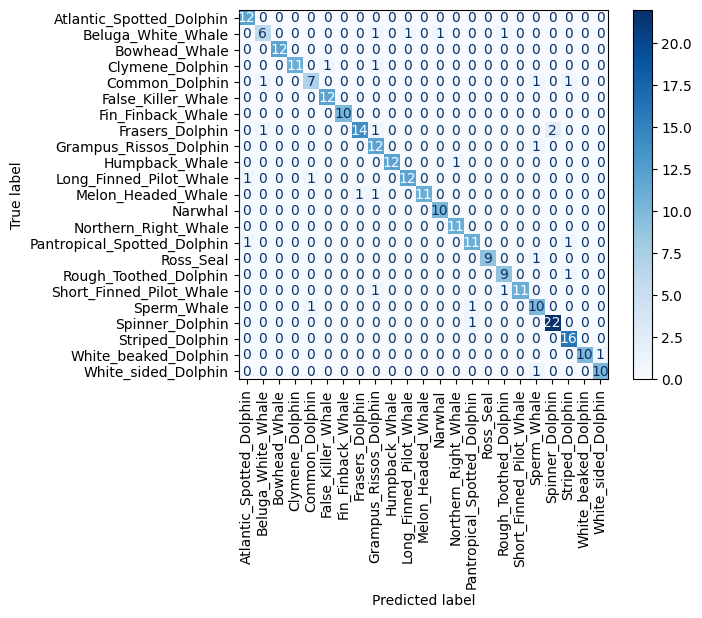

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        outputs = model(X)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=dataset.class_names))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset.class_names)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.show()


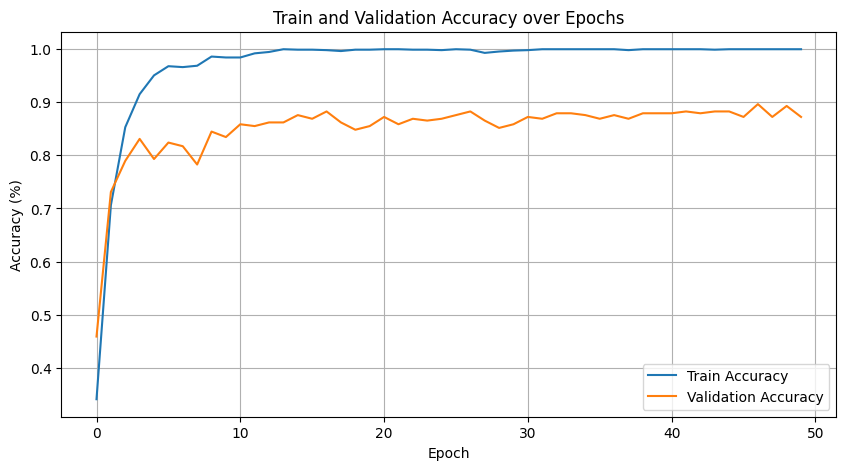

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

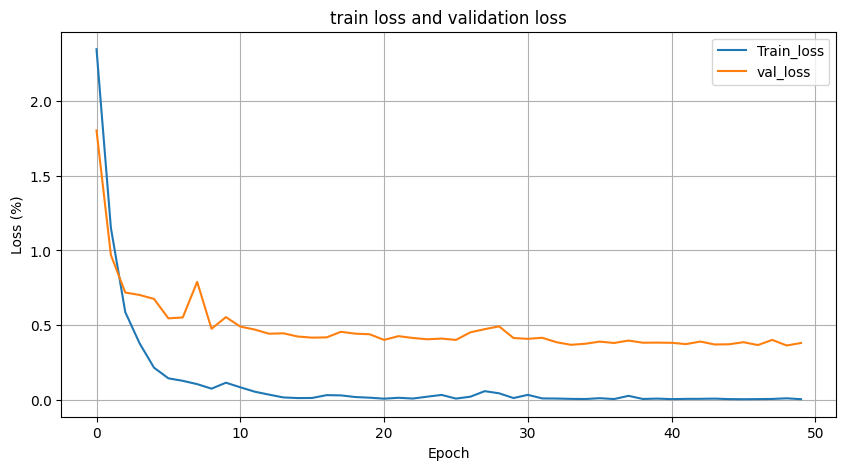

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train_loss')
plt.plot(val_loss_history, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (%)')
plt.title('train loss and validation loss')
plt.legend()
plt.grid(True)
plt.show()

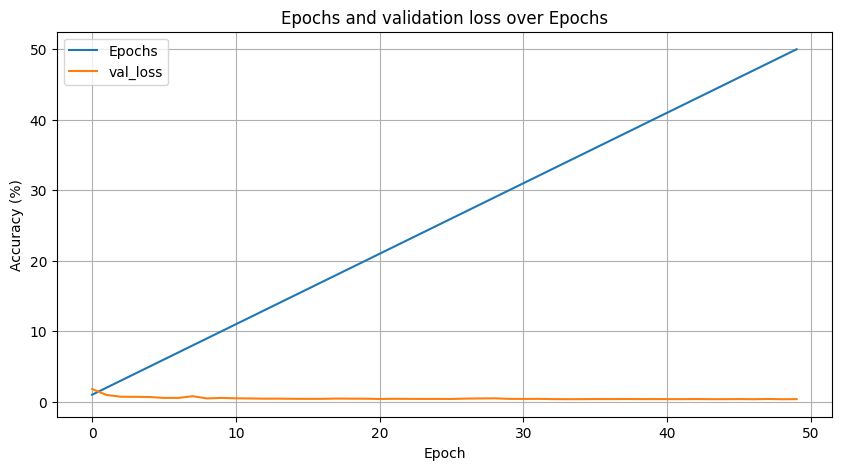

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(epochs_count, label='Epochs')
plt.plot(val_loss_history, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Epochs and validation loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# torch.save(model.state_dict(), "sound_model.pth")


In [ ]:
# import json

# with open("labels.json", "w") as f:
#     json.dump(dataset.class_names, f)

# print("Exported labels:", dataset.class_names)